# Operaciones basicas y ejemplo del MNIST


In [1]:
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt

In [16]:
# ================================
# Parámetros del modelo y de los datos
# ================================

num_classes = 10  
# Número de clases a predecir (dígitos del 0 al 9)

input_shape = (28, 28, 1)  
# Forma de cada imagen: 28x28 píxeles y 1 canal (escala de grises)


# ================================
# Carga del dataset MNIST
# ================================

# Carga los datos y los divide automáticamente en entrenamiento y prueba
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [18]:
x_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

## Preprocesamiento

In [12]:
# ================================
# Preprocesamiento de imágenes
# ================================

# Convierte los valores a tipo float32 y escala los píxeles al rango [0, 1]
# (originalmente están en el rango [0, 255])
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Añade una dimensión extra al final para indicar el canal (1 canal)
# Pasa de (28, 28) a (28, 28, 1)
# Esto es necesario para trabajar con redes convolucionales
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

In [14]:
# Imprime la forma final del conjunto de entrenamiento
print("x_train shape:", x_train.shape)

# Muestra el número total de imágenes de entrenamiento
print(x_train.shape[0], "train samples")

# Muestra el número total de imágenes de prueba
print(x_test.shape[0], "test samples")

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


## Codificación de las etiquetas

In [25]:
num_classes

10

In [21]:
# Convierte las etiquetas numéricas (0-9)
# en vectores binarios (one-hot encoding)
# Ejemplo: 3 → [0,0,0,1,0,0,0,0,0,0]
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

Training data shape: (60000, 28, 28)
Training labels shape: (60000, 10)


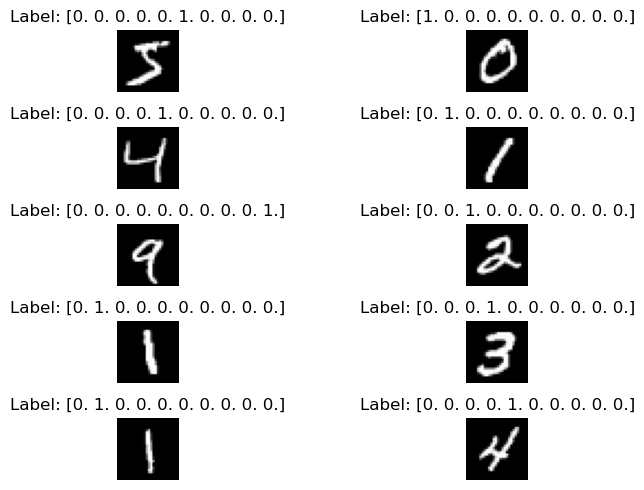

In [33]:
# ================================
# Verificación de dimensiones
# ================================

# Imprime la forma del conjunto de entrenamiento (número de imágenes y dimensiones)
print(f"Training data shape: {x_train.shape}")

# Imprime la forma de las etiquetas (ya codificadas en one-hot)
print(f"Training labels shape: {y_train.shape}")


# ================================
# Visualización de las primeras imágenes
# ================================

# Crea una figura con tamaño 10x5 pulgadas
plt.figure(figsize=(10, 5))

# Itera sobre las primeras 10 imágenes del conjunto de entrenamiento
for i in range(10):
    
    # Crea una subgráfica en una cuadrícula de 2 filas x 5 columnas
    # i + 1 indica la posición del subplot (empieza en 1, no en 0)
    plt.subplot(5, 2, i + 1)
    
    # Muestra la imagen (28x28 píxeles)
    # cmap='gray' indica que es una imagen en escala de grises
    plt.imshow(x_train[i], cmap='gray')
    
    # Muestra la etiqueta correspondiente como título
    # Si está en one-hot, mostrará el vector binario
    plt.title(f"Label: {y_train[i]}")
    
    # Oculta los valores de los ejes para que la imagen se vea más limpia
    plt.axis('off')

# Ajusta automáticamente los espacios entre subgráficas
plt.tight_layout()

# Muestra la figura completa
plt.show()

In [35]:
# ================================
# Definición del modelo CNN
# ================================

# Se crea un modelo secuencial (las capas se apilan una tras otra)
model = keras.Sequential(
    [
        # Capa de entrada
        # Define la forma de los datos que recibirá el modelo (28, 28, 1)
        keras.Input(shape=input_shape),

        # Primera capa convolucional
        # 32 filtros (kernels) de tamaño 3x3
        # activation="relu" introduce no linealidad
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),

        # Capa de reducción de dimensionalidad. Reduce el tamaño espacial usando ventanas 2x2. Conserva las características más relevantes
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Segunda capa convolucional
        # 64 filtros de tamaño 3x3 (detecta patrones más complejos)
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),

        # Segunda capa de pooling
        # Vuelve a reducir la dimensión espacial
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Aplana la salida 2D en un vector 1D
        # Necesario para conectarlo con capas densas (fully connected)
        layers.Flatten(),

        # Capa Dropout
        # Desactiva aleatoriamente el 50% de las neuronas en entrenamiento
        # Ayuda a reducir el sobreajuste (overfitting)
        layers.Dropout(0.5),

        # Capa de salida (fully connected)
        # num_classes neuronas (10 en MNIST)
        # softmax convierte las salidas en probabilidades
        layers.Dense(num_classes, activation="softmax"),
    ]
)
model

In [37]:
# Muestra un resumen de la arquitectura del modelo:
# capas, dimensiones de salida y número de parámetros entrenables
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dropout (Dropout)           (None, 1600)              0

# Interpretación matemática del model.summary()

Sea una entrada de dimensión:

$$
H \times W \times C
$$

donde:
- $H$ = altura  
- $W$ = ancho  
- $C$ = canales  

---

Para una capa convolucional sin padding y con stride $S$:

$$
H_{out} = \frac{H - F}{S} + 1
$$

$$
W_{out} = \frac{W - F}{S} + 1
$$

El número de canales de salida es:

$$
C_{out} = \text{número de filtros}
$$

El número de parámetros es:

$$
\text{Params} = (F \cdot F \cdot C_{in} + 1)\cdot C_{out}
$$

(donde el $+1$ corresponde al sesgo por filtro)

---

Aplicación al modelo:

Entrada:

$$
(28, 28, 1)
$$

Primera convolución ($F=3$, $S=1$, $C_{out}=32$):

$$
H_{out} = \frac{28-3}{1}+1 = 26
$$

Salida:

$$
(26,26,32)
$$

Parámetros:

$$
(3\cdot3\cdot1 + 1)\cdot32 = 320
$$

---

MaxPooling $(2\times2)$:

$$
H_{out} = \left\lfloor \frac{H}{2} \right\rfloor
$$

$$
(26,26,32) \rightarrow (13,13,32)
$$

(No tiene parámetros)

---

Segunda convolución ($F=3$, $C_{in}=32$, $C_{out}=64$):

$$
H_{out} = \frac{13-3}{1}+1 = 11
$$

Salida:

$$
(11,11,64)
$$

Parámetros:

$$
(3\cdot3\cdot32 + 1)\cdot64 = 18,496
$$

---

Segundo MaxPooling:

$$
(11,11,64) \rightarrow (5,5,64)
$$

---

Flatten:

$$
5\cdot5\cdot64 = 1600
$$

---

Capa densa (10 clases):

$$
\text{Params} = (1600 \cdot 10) + 10 = 16,010
$$

---

Total de parámetros:

$$
320 + 18,496 + 16,010 = 34,826
$$

In [43]:
128*15

1920

In [45]:
# ================================
# Hiperparámetros de entrenamiento
# ================================

batch_size = 128  
# Número de muestras que el modelo procesa antes de actualizar los pesos.
# Es decir, los datos se dividen en grupos de 128 imágenes.
# Un batch más grande suele hacer el entrenamiento más estable,
# pero consume más memoria.

epochs = 15  
# Número de veces que el modelo recorrerá todo el conjunto de entrenamiento.
# 1 epoch = ver todos los datos una vez completa.


# ================================
# Compilación del modelo
# ================================

model.compile(
    loss="categorical_crossentropy",  
    # Función de pérdida para clasificación multiclase
    # (cuando las etiquetas están en formato one-hot).

    optimizer="adam",  
    # Algoritmo de optimización que ajusta los pesos.
    # Adam combina Momentum y RMSprop, es rápido y funciona bien por defecto.

    metrics=["accuracy"]  
    # Métrica que se mostrará durante el entrenamiento.
    # En este caso, porcentaje de predicciones correctas.
)


# ================================
# Entrenamiento del modelo
# ================================

model.fit(
    x_train, y_train,               # Datos de entrada y etiquetas
    batch_size=batch_size,          # Tamaño del batch (128)
    epochs=epochs,                  # Número de épocas (15)
    validation_split=0.1            # 10% del conjunto de entrenamiento
                                    # se usa para validación (no entrena con ellos)
)

Epoch 1/15
422/422 [==============================] - 40s 88ms/step - loss: 1.2363 - accuracy: 0.8504 - val_loss: 0.0775 - val_accuracy: 0.9773
Epoch 2/15
422/422 [==============================] - 40s 95ms/step - loss: 0.1662 - accuracy: 0.9491 - val_loss: 0.0505 - val_accuracy: 0.9858
Epoch 3/15
422/422 [==============================] - 47s 111ms/step - loss: 0.1217 - accuracy: 0.9619 - val_loss: 0.0464 - val_accuracy: 0.9862
Epoch 4/15
422/422 [==============================] - 45s 106ms/step - loss: 0.1017 - accuracy: 0.9686 - val_loss: 0.0423 - val_accuracy: 0.9897
Epoch 5/15
422/422 [==============================] - 43s 102ms/step - loss: 0.0903 - accuracy: 0.9719 - val_loss: 0.0418 - val_accuracy: 0.9887
Epoch 6/15
422/422 [==============================] - 37s 87ms/step - loss: 0.0822 - accuracy: 0.9735 - val_loss: 0.0407 - val_accuracy: 0.9885
Epoch 7/15
422/422 [==============================] - 37s 87ms/step - loss: 0.0727 - accuracy: 0.9784 - val_loss: 0.0412 - val_accura

In [47]:
# ================================
# Evaluación del modelo
# ================================

# Evalúa el modelo usando el conjunto de prueba (datos que el modelo nunca vio)
# Devuelve una lista con los valores de la pérdida y las métricas definidas en compile()
score = model.evaluate(x_test, y_test, verbose=0)

# verbose=0 significa que no se mostrará la barra de progreso durante la evaluación


# ================================
# Resultados
# ================================

# score[0] corresponde a la función de pérdida (loss)
# En este caso, categorical_crossentropy
print("Test loss:", score[0])

# score[1] corresponde a la métrica definida: accuracy
# Representa el porcentaje de predicciones correctas en el conjunto de prueba
print("Test accuracy:", score[1])

Test loss: 0.03211142122745514
Test accuracy: 0.9900000095367432


# Modelo propio para fashion Mnist

4422102/4422102 [==============================] - 0s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)


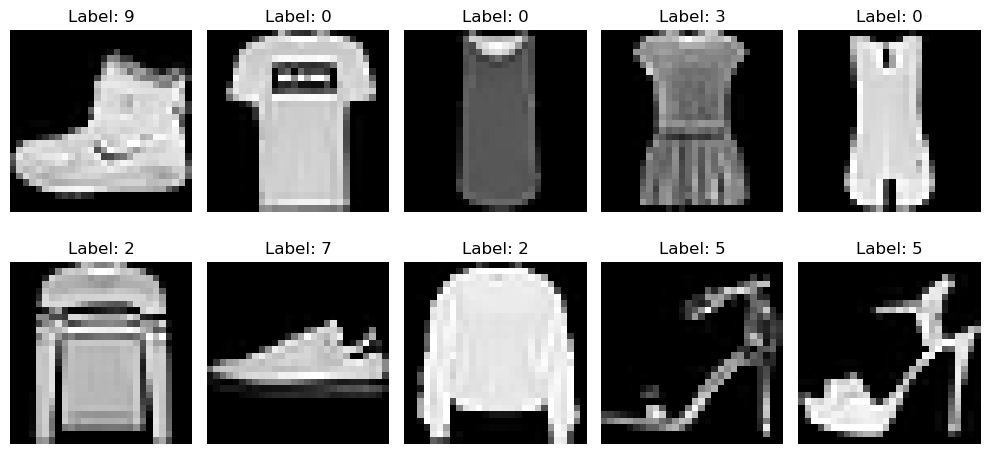

In [51]:
# ================================
# Carga del dataset Fashion MNIST
# ================================

# Carga el conjunto de datos Fashion-MNIST
# Devuelve:
# x_train → imágenes de entrenamiento
# y_train → etiquetas de entrenamiento
# x_test → imágenes de prueba
# y_test → etiquetas de prueba
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()


# ================================
# Verificación de dimensiones
# ================================

# Muestra la forma del conjunto de entrenamiento
# (número de imágenes, alto, ancho)
print(f"Training data shape: {x_train.shape}")

# Muestra la forma de las etiquetas
# (número de etiquetas,)
print(f"Training labels shape: {y_train.shape}")


# ================================
# Visualización de imágenes
# ================================

# Crea una figura de tamaño 10x5 pulgadas
plt.figure(figsize=(10, 5))

# Itera sobre las primeras 10 imágenes
for i in range(10):
    
    # Crea una subgráfica en una cuadrícula de 2 filas x 5 columnas
    plt.subplot(2, 5, i + 1)
    
    # Muestra la imagen (28x28 píxeles en escala de grises)
    plt.imshow(x_train[i], cmap='gray')
    
    # Muestra como título la etiqueta numérica correspondiente
    # (cada número representa una categoría de prenda)
    plt.title(f"Label: {y_train[i]}")
    
    # Oculta los ejes para una visualización más limpia
    plt.axis('off')

# Ajusta automáticamente los espacios entre subgráficas
plt.tight_layout()

# Muestra la figura completa
plt.show()

In [53]:
# ================================
# Normalización de las imágenes
# ================================

# Convierte los valores de los píxeles a tipo float32
# y los escala al rango [0, 1].
# Originalmente los píxeles están en el rango [0, 255].
# Esto mejora la estabilidad numérica y acelera el entrenamiento.
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255


# ================================
# Ajuste de dimensiones (canal)
# ================================

# Añade una dimensión extra al final para indicar el canal.
# Pasa de (28, 28) a (28, 28, 1).
# Es necesario porque las capas Conv2D esperan datos en formato:
# (alto, ancho, canales).
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)


# ================================
# Verificación de datos
# ================================

# Muestra la nueva forma del conjunto de entrenamiento
print("x_train shape:", x_train.shape)

# Número total de imágenes de entrenamiento
print(x_train.shape[0], "train samples")

# Número total de imágenes de prueba
print(x_test.shape[0], "test samples")


# ================================
# Codificación de etiquetas (One-Hot Encoding)
# ================================

# Convierte las etiquetas numéricas (por ejemplo: 3)
# en vectores binarios:
# 3 → [0,0,0,1,0,0,0,0,0,0]
# Esto es necesario cuando se usa
# loss="categorical_crossentropy"
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [55]:
# ================================
# Definición del modelo CNN
# ================================

# Se crea un modelo secuencial:
# Las capas se ejecutan una después de la otra.
model = keras.Sequential(
    [
        # Capa de entrada
        # Define la forma esperada de cada imagen (alto, ancho, canales)
        keras.Input(shape=input_shape),

        # ================================
        # Bloque Convolucional 1
        # ================================
        
        # 32 filtros de tamaño 3x3
        # Detecta patrones simples como bordes y líneas
        # ReLU introduce no linealidad
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        
        # Reduce la dimensión espacial a la mitad (2x2)
        # Mantiene las características más relevantes
        layers.MaxPooling2D(pool_size=(2, 2)),

        # ================================
        # Bloque Convolucional 2
        # ================================
        
        # 64 filtros de tamaño 3x3
        # Detecta patrones más complejos combinando los anteriores
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        
        # Nueva reducción espacial
        layers.MaxPooling2D(pool_size=(2, 2)),

        # ================================
        # Bloque Convolucional 3
        # ================================
        
        # 128 filtros de tamaño 3x3
        # Aprende representaciones aún más abstractas
        # (partes de objetos o estructuras más complejas)
        layers.Conv2D(128, kernel_size=(3, 3), activation="relu"),

        # ================================
        # Transición a capas densas
        # ================================
        
        # Convierte el volumen 3D en un vector 1D
        # Necesario para conectarlo con la capa final
        layers.Flatten(),

        # Dropout desactiva aleatoriamente el 50% de neuronas
        # durante el entrenamiento para reducir overfitting
        layers.Dropout(0.5),

        # ================================
        # Capa de salida
        # ================================
        
        # Capa totalmente conectada con tantas neuronas
        # como clases haya (num_classes)
        # Softmax convierte las salidas en probabilidades
        layers.Dense(num_classes, activation="softmax"),
    ]
)

# Muestra el resumen del modelo:
# - Dimensiones de salida
# - Número de parámetros por capa
# - Total de parámetros entrenables
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 13, 13, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 3, 3, 128)         73856     
                                                                 
 flatten_1 (Flatten)         (None, 1152)             

In [57]:
# ================================
# Definición de hiperparámetros
# ================================

batch_size = 128   # Número de muestras procesadas antes de actualizar los pesos
epochs = 15        # Número de veces que el modelo recorrerá todo el dataset


# ================================
# Compilación del modelo
# ================================

model.compile(
    loss="categorical_crossentropy",  # Función de pérdida para clasificación multiclase (one-hot encoding)
    optimizer="adam",                 # Optimizador adaptativo eficiente para deep learning
    metrics=["accuracy"]              # Métrica de evaluación durante el entrenamiento
)


# ================================
# Entrenamiento del modelo
# ================================

history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1,  # 10% de los datos se usan para validación
    shuffle=True           # Mezcla los datos en cada epoch para mejor generalización
)

Epoch 1/15
422/422 [==============================] - 46s 104ms/step - loss: 0.6875 - accuracy: 0.7467 - val_loss: 0.4367 - val_accuracy: 0.8342
Epoch 2/15
422/422 [==============================] - 42s 99ms/step - loss: 0.4382 - accuracy: 0.8398 - val_loss: 0.3841 - val_accuracy: 0.8588
Epoch 3/15
422/422 [==============================] - 44s 103ms/step - loss: 0.3768 - accuracy: 0.8641 - val_loss: 0.3521 - val_accuracy: 0.8682
Epoch 4/15
422/422 [==============================] - 43s 102ms/step - loss: 0.3430 - accuracy: 0.8762 - val_loss: 0.3100 - val_accuracy: 0.8850
Epoch 5/15
422/422 [==============================] - 44s 103ms/step - loss: 0.3201 - accuracy: 0.8829 - val_loss: 0.2951 - val_accuracy: 0.8900
Epoch 6/15
422/422 [==============================] - 42s 98ms/step - loss: 0.2992 - accuracy: 0.8899 - val_loss: 0.3026 - val_accuracy: 0.8890
Epoch 7/15
422/422 [==============================] - 46s 108ms/step - loss: 0.2874 - accuracy: 0.8934 - val_loss: 0.2710 - val_accu

In [58]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.25010016560554504
Test accuracy: 0.9057000279426575
